# Cached Prediction EDA (All Genes)

Streamlined analysis notebook for cached LORO outputs with all-genes model fits.


In [1]:
from pathlib import Path
import sys
import pandas as pd

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src").exists() and (REPO_ROOT.parent / "src").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.eval_utils.results_eda import *


In [2]:
import importlib
import src.eval_utils.results_eda
importlib.reload(src.eval_utils.results_eda)

<module 'src.eval_utils.results_eda' from '/scratch/asr655/neuroinformatics/Seq2GeneEx/gtex_gp/src/eval_utils/results_eda.py'>

In [3]:
set_academic_style()

CFG = EDAConfig(
    csv_path='data/raw/gxp_samples.csv',
    hvg_path='data/raw/ahba_100hvg.txt',
    cache_root='out/loro_subject_cache', # or loro_subject_cache_arxiv
    gene_scope='allgenes',
    plam_cache_dirname='plam'
)
CFG
print('analysis scope:', CFG.gene_scope)


analysis scope: allgenes


## 1) Dataset Attributes


In [4]:
PREPOST = prepare_pre_post_harmonization(CFG)
print('subjects:', len(PREPOST['subjects']))
print('genes:', len(PREPOST['genes']))
print('parcels:', PREPOST['raw_cube'].shape[1])


subjects: 318
genes: 13618
parcels: 150


In [6]:
# label_mode: 'ahba' | 'gtex' | 'both'
LABEL_MODE = 'both'
ELIGIBLE_ONLY = True

count_df = parcel_subject_count_table(PREPOST, label_mode=LABEL_MODE, eligible_only=ELIGIBLE_ONLY)
n_pool = int(count_df['n_subjects_pool'].iloc[0])
print(f'n (subjects in pool) = {n_pool}; eligible_only={ELIGIBLE_ONLY}')
count_df[['parcel_idx','ahba_parcel','gtex_native','n_subjects_observed','n_samples','label']].head(12)


n (subjects in pool) = 318; eligible_only=True


,parcel_idx,ahba_parcel,gtex_native,n_subjects_observed,n_samples,label
0,10,LH-Ca,caudate (basal ganglia),279,279,LH-Ca: caudate (basal ganglia)
1,18,LH-NAC,nucleus accumbens (basal ganglia),273,273,LH-NAC: nucleus accumbens (basal ganglia)
2,5,Cerebellar_Region5,cerebellar hemisphere,262,262,Cerebellar_Region5: cerebellar hemisphere
3,38,LH_Default_PFC_5,frontal cortex (ba9),252,252,LH_Default_PFC_5: frontal cortex (ba9)
4,0,Cerebellar_Region1,cerebellum,251,251,Cerebellar_Region1: cerebellum
5,19,LH-Pu,putamen (basal ganglia),250,250,LH-Pu: putamen (basal ganglia)
6,16,LH-HTH,hypothalamus,242,242,LH-HTH: hypothalamus
7,31,LH_Cont_PFCl_1,cortex,240,240,LH_Cont_PFCl_1: cortex
8,55,LH_Hippocampus,hippocampus,240,240,LH_Hippocampus: hippocampus
9,132,RH_SalVentAttn_Med_2,anterior cingulate cortex (ba24),223,223,RH_SalVentAttn_Med_2: anterior cingulate corte...


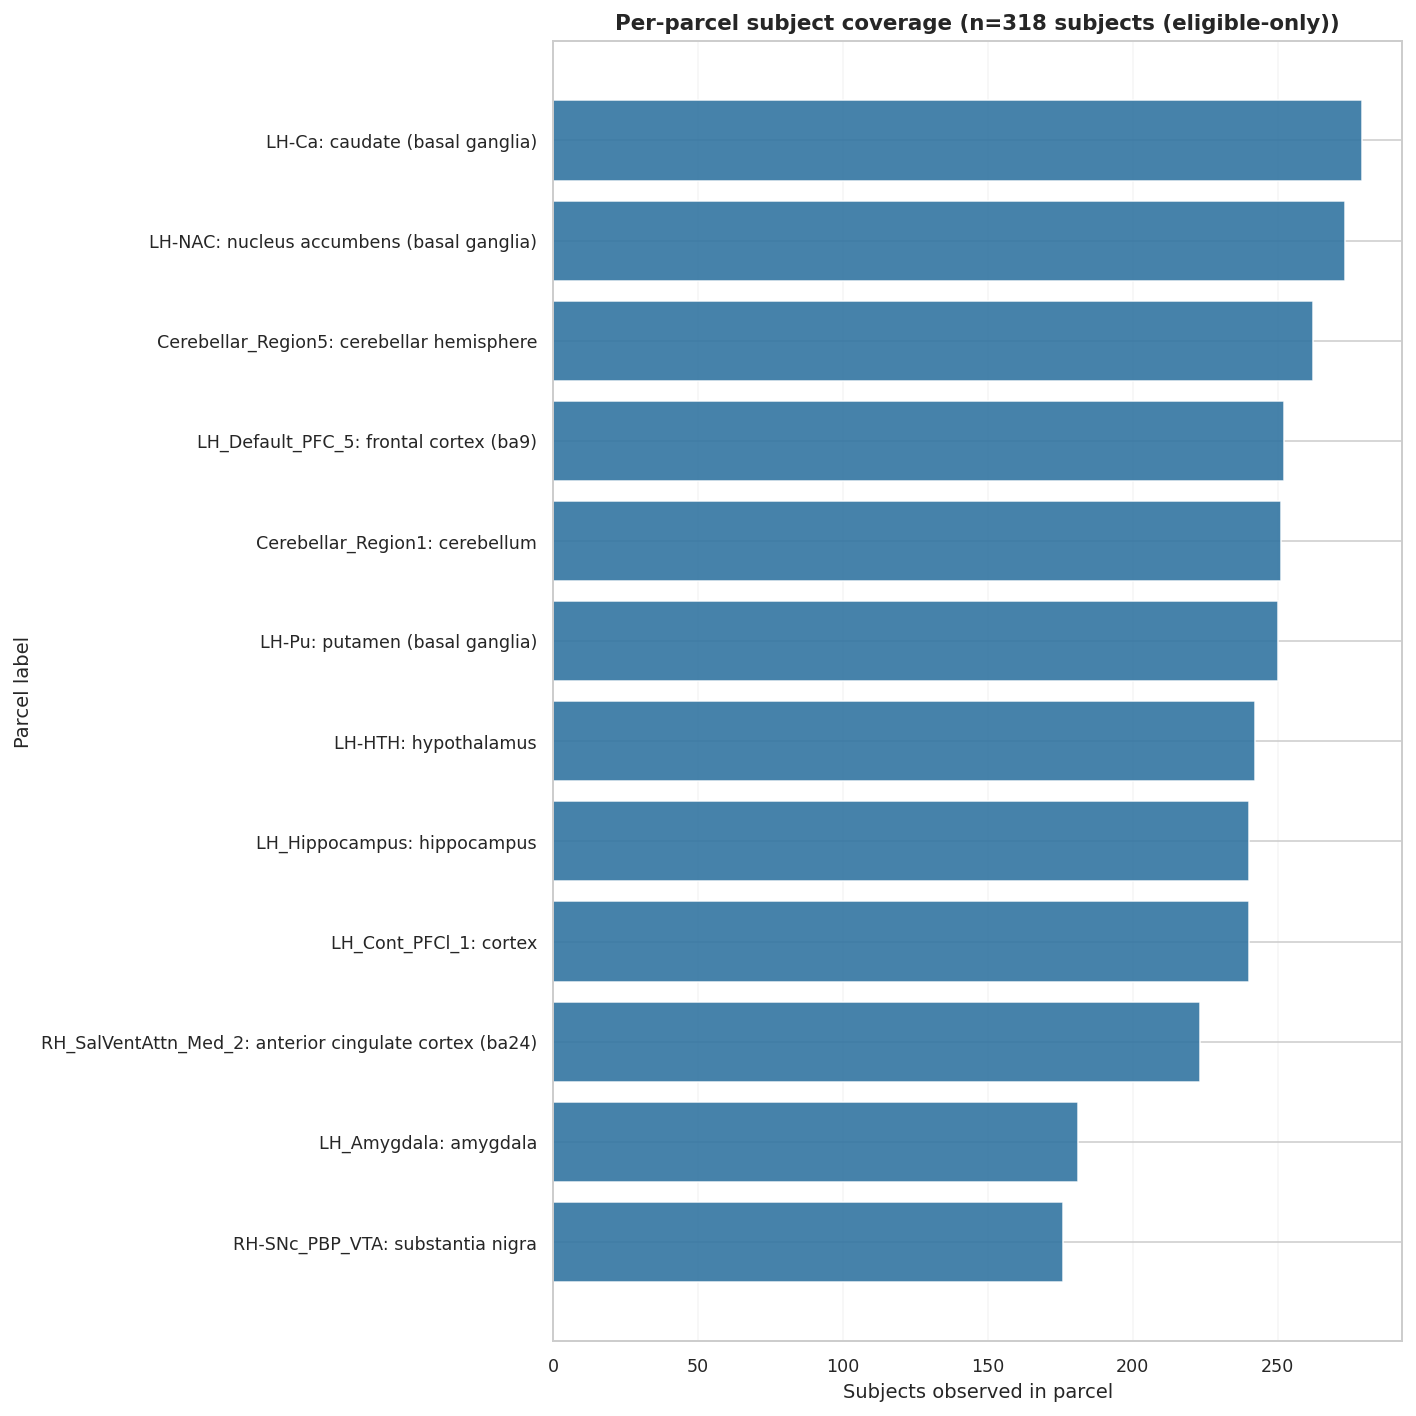

In [7]:
fig_h = max(8.0, 0.20 * len(count_df))
fig, ax = plot_parcel_subject_counts(count_df, top_n=None, min_subjects=1, figsize=(10, 10))


,n_regions_sampled,n_subjects,eligible_only,n_subjects_pool
0,5,21,True,318
1,6,29,True,318
2,7,36,True,318
3,8,29,True,318
4,9,53,True,318
5,10,54,True,318
6,11,63,True,318
7,12,33,True,318


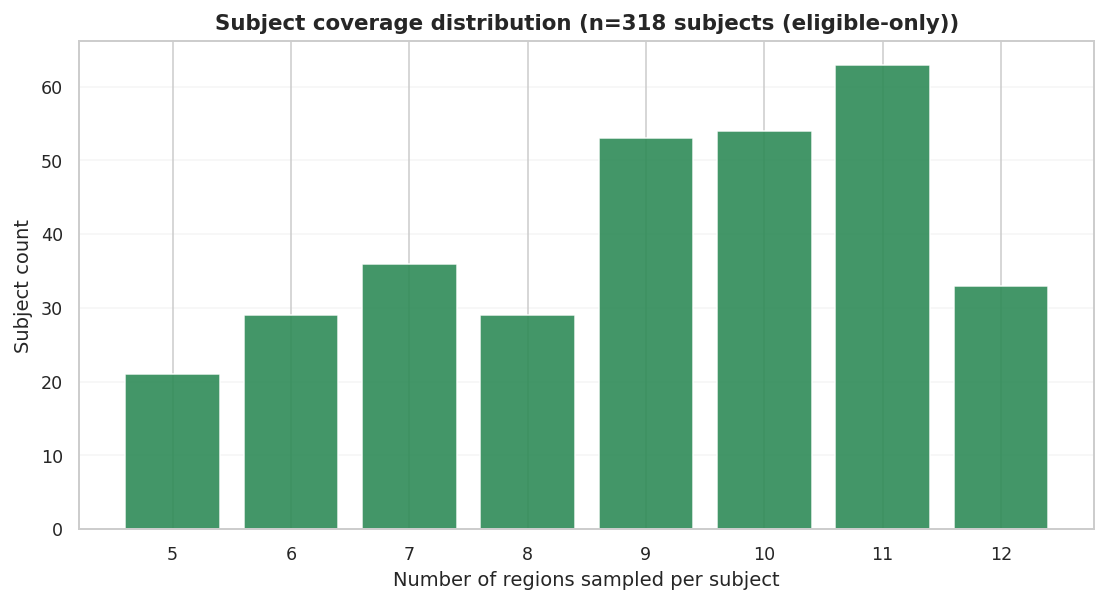

In [8]:
# LORO-relevant: x=regions sampled per subject, y=subject count
subj_cov = subject_region_count_distribution(PREPOST, eligible_only=ELIGIBLE_ONLY)
display(subj_cov)
fig, ax = plot_subject_region_count_distribution(subj_cov)


## 2) Pre/Post ComBat Diagnostics


In [9]:
# gene_mode: 'hvg' | 'allgenes' | 'custom'
GENE_MODE = 'hvg'
CUSTOM_GENE_LIST = None

atlas_cmp = prepare_atlas_median_comparison(
    PREPOST,
    gene_mode=GENE_MODE,
    gene_list=CUSTOM_GENE_LIST,
    observed_only=True,
)
print('atlas parcels:', len(atlas_cmp['parcel_labels']))
print('genes in panel:', len(atlas_cmp['genes']))


atlas parcels: 12
genes in panel: 88


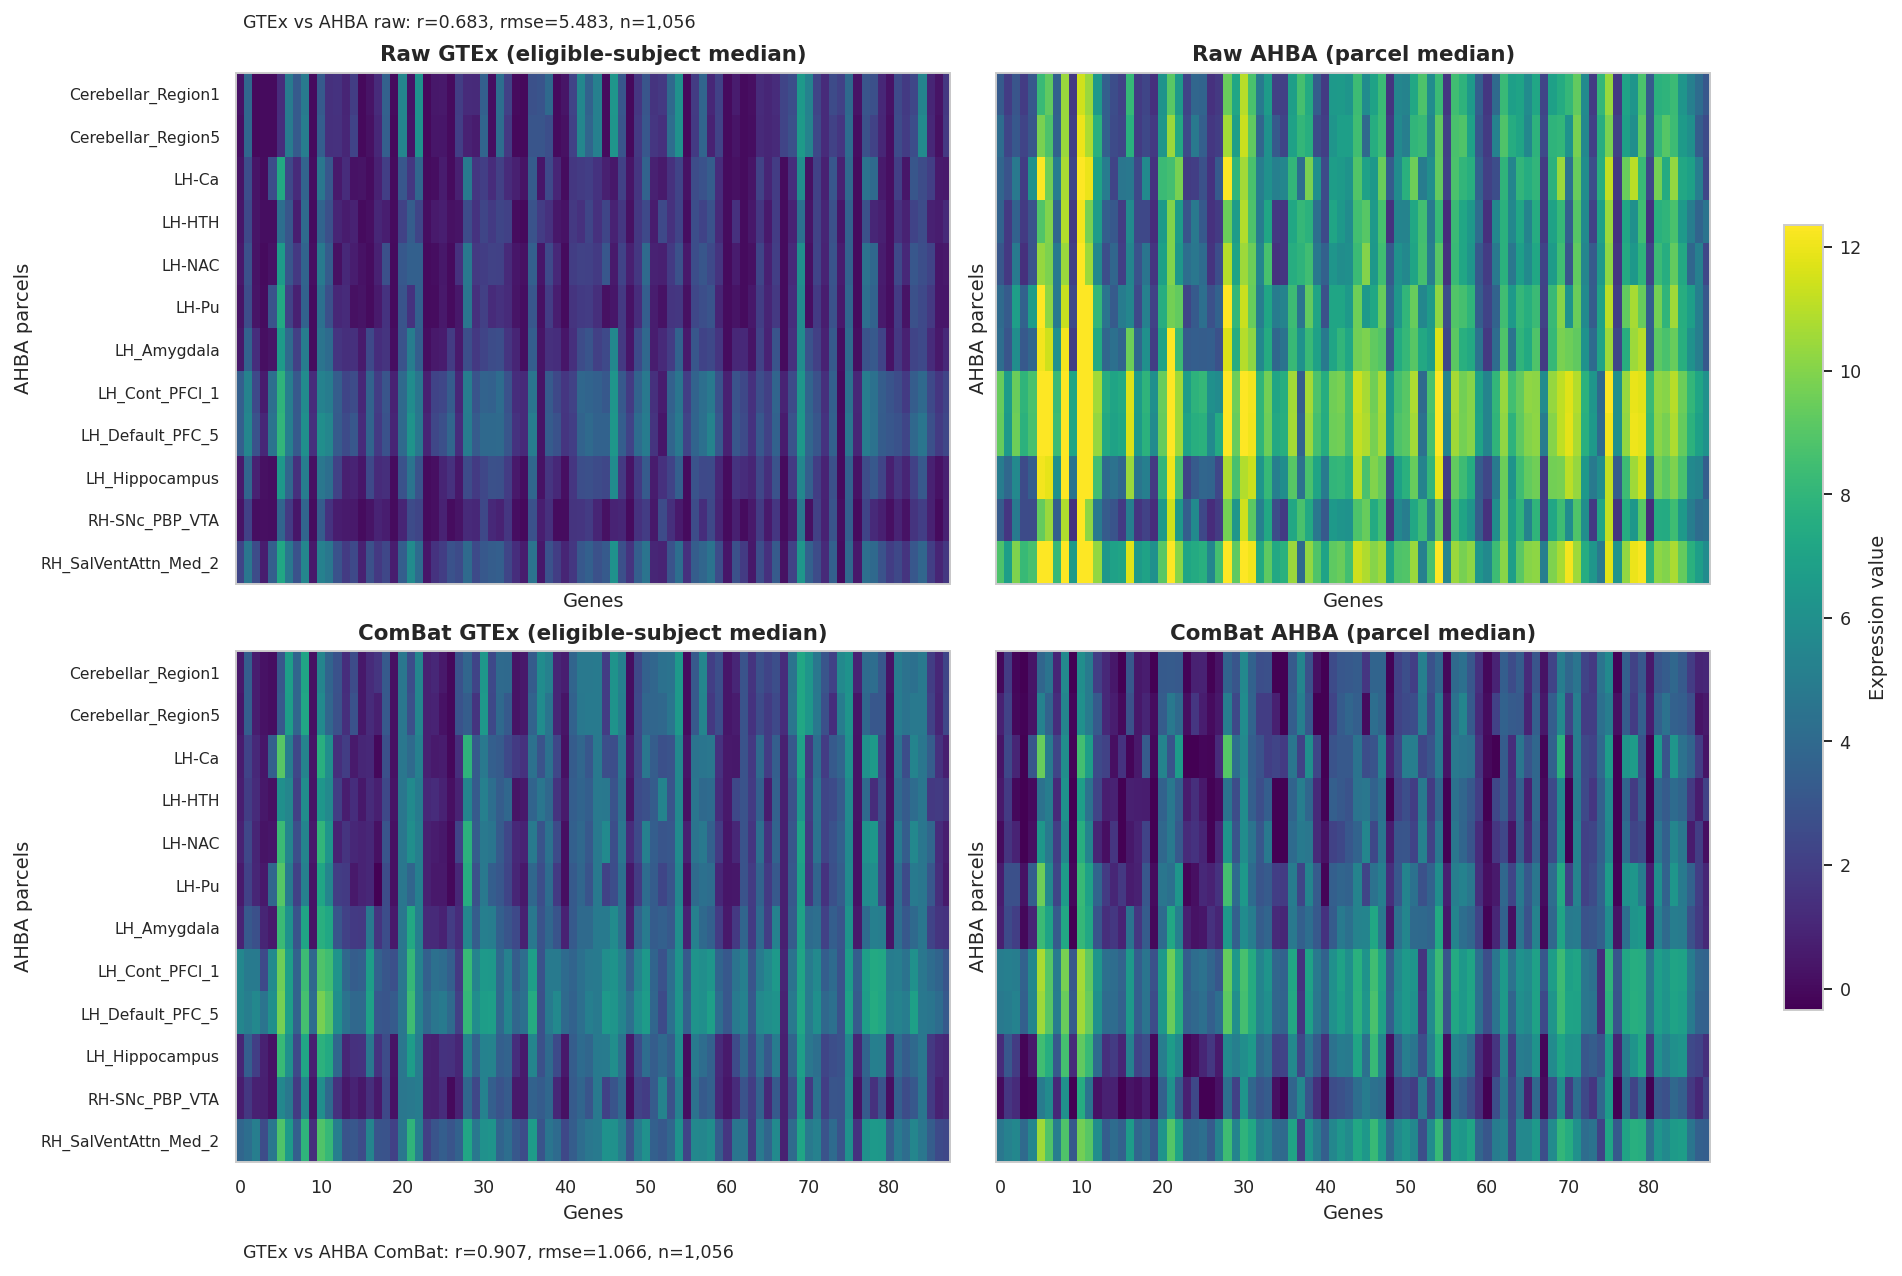

In [10]:
fig, axes = plot_atlas_median_comparison_heatmaps(atlas_cmp, label_stride=1)


subject: GTEX-1117F


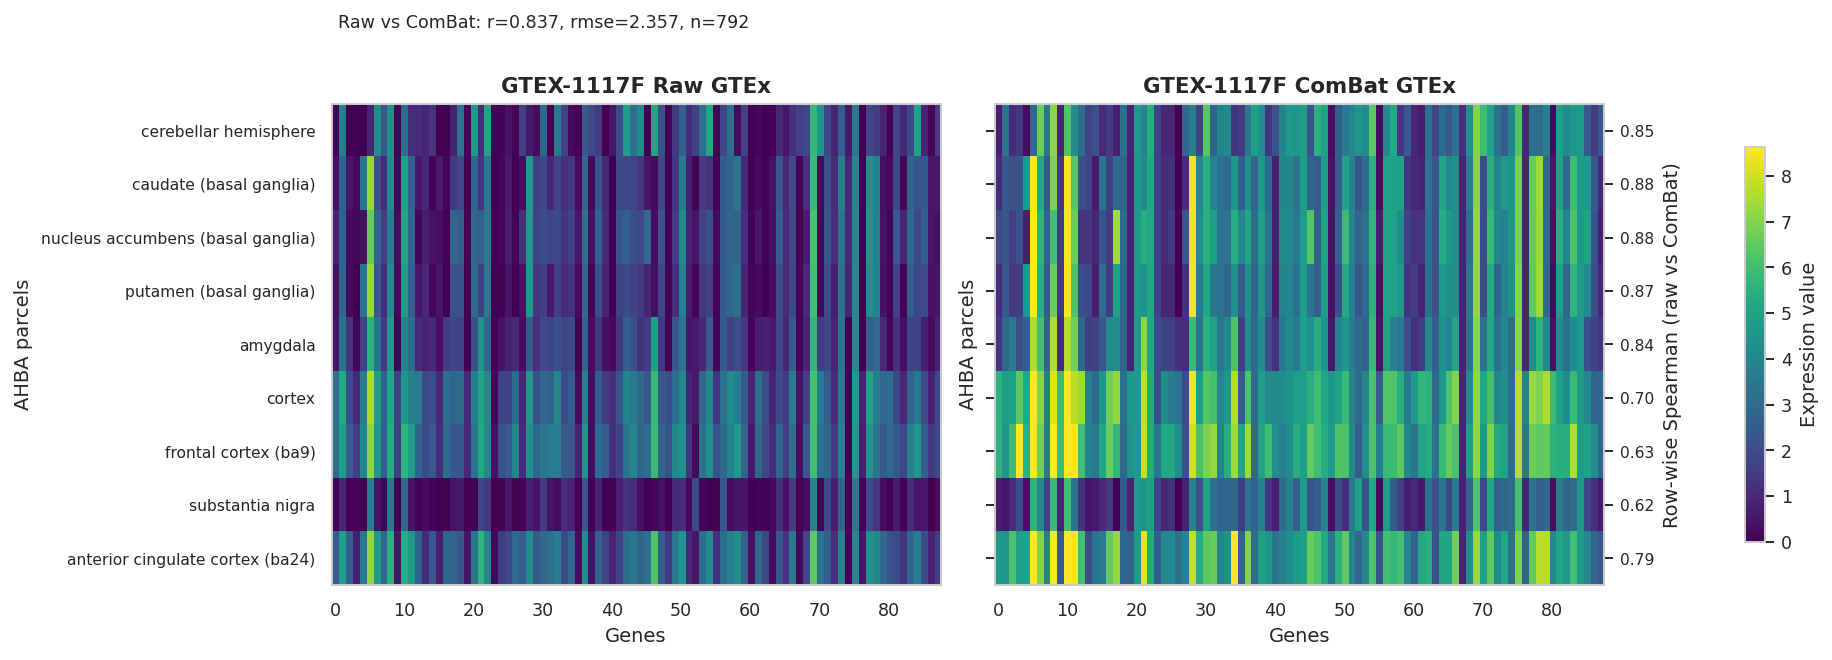

In [11]:
# Single-subject pre/post (GTEx only)
SUBJECT_ID = PREPOST['subjects'][0]
fig, axes = plot_subject_prepost_heatmaps(
    PREPOST,
    subject_id=SUBJECT_ID,
    gene_mode=GENE_MODE,
    gene_list=CUSTOM_GENE_LIST,
    observed_only=True,
    label_stride=1,
)
print('subject:', SUBJECT_ID)


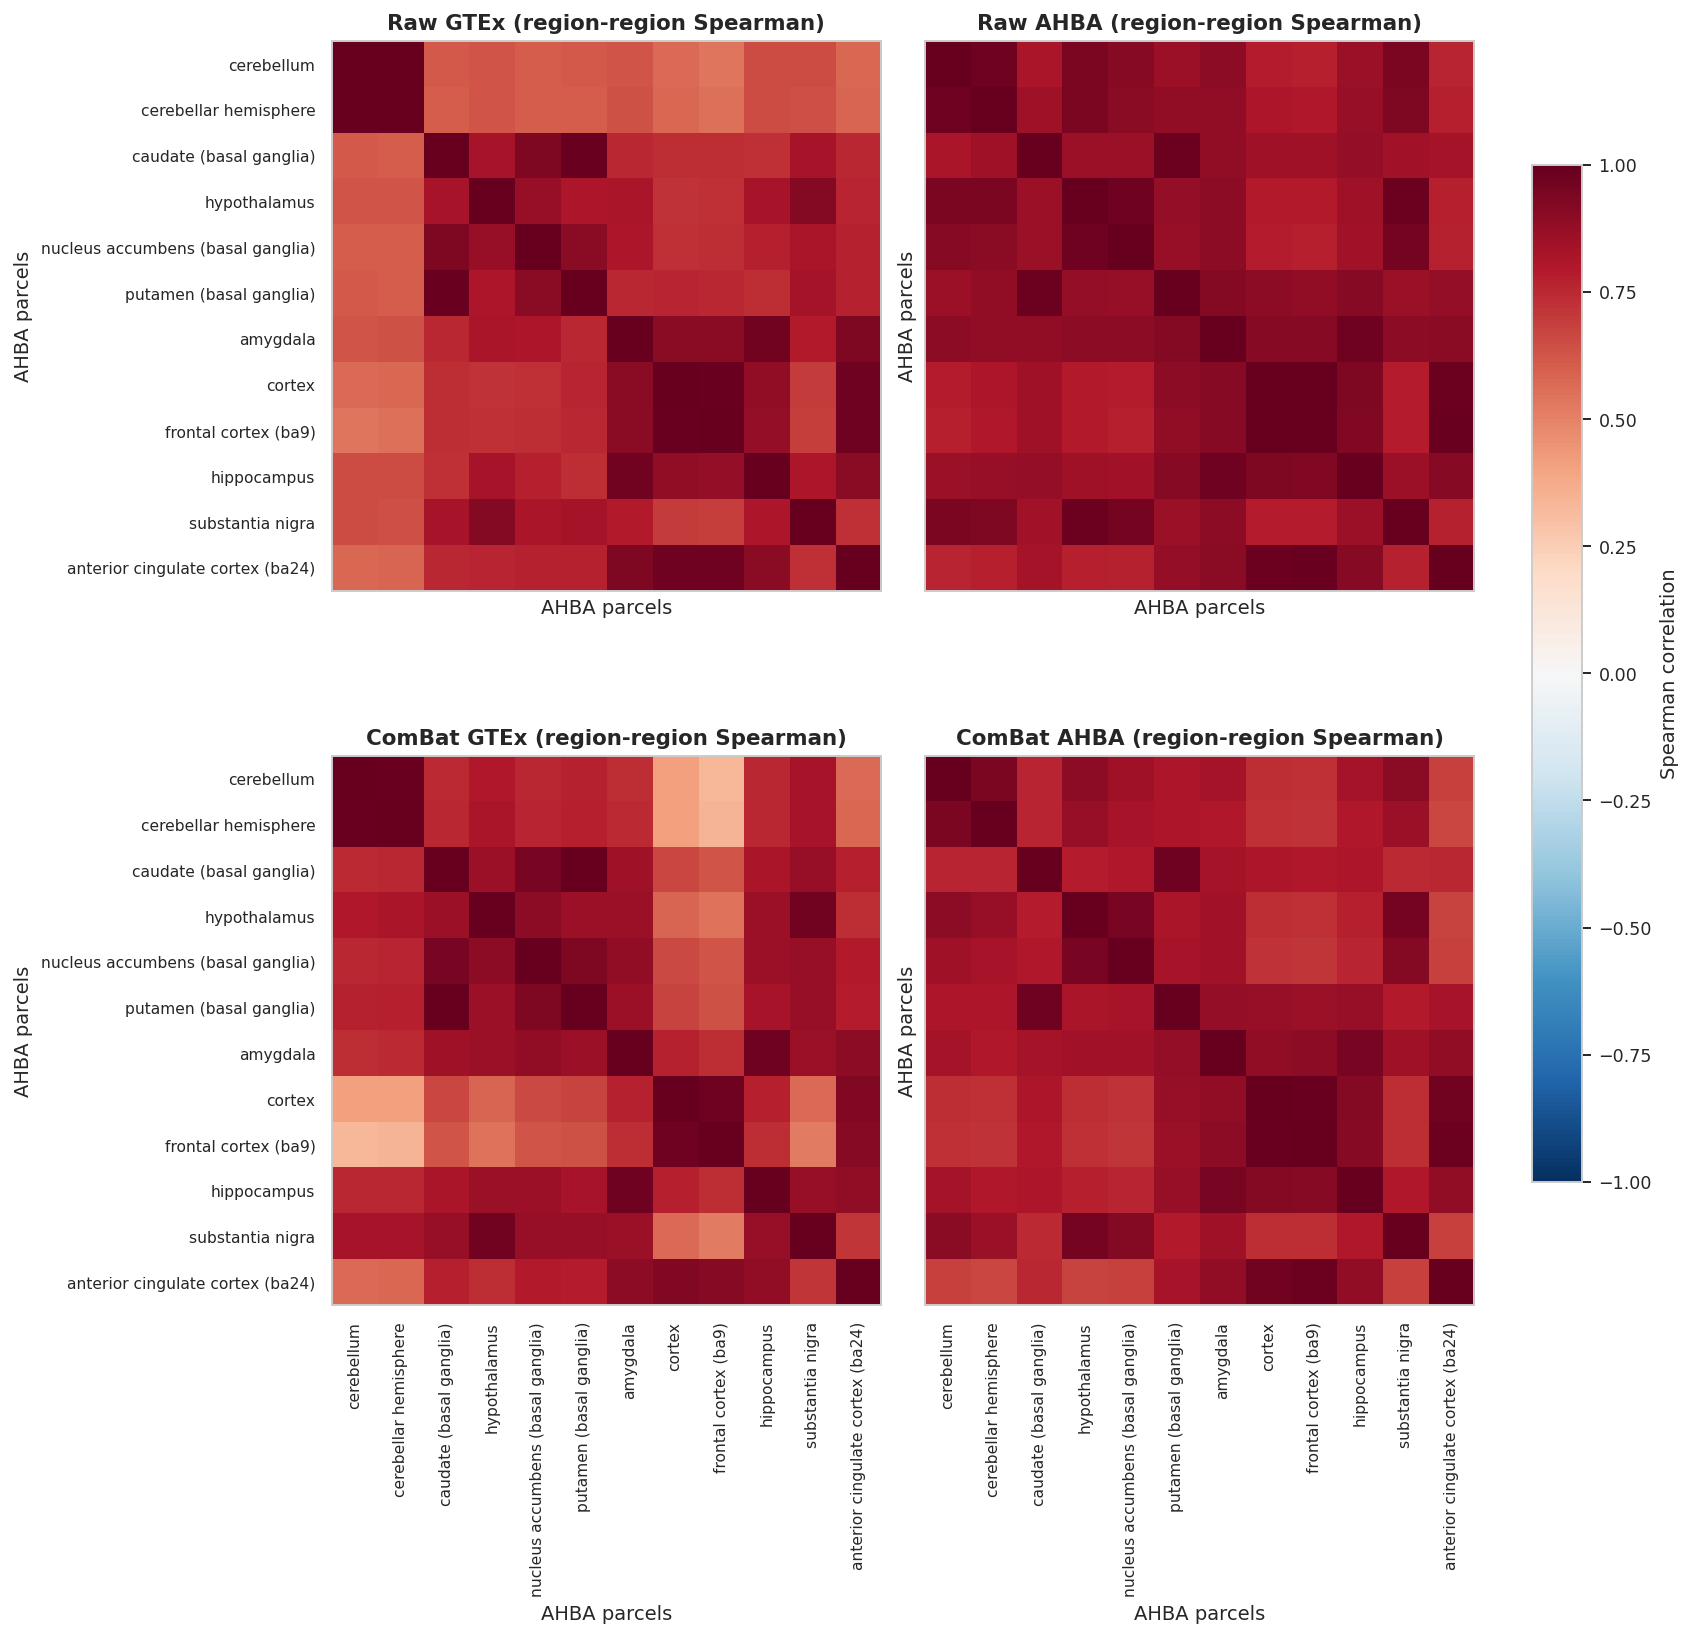

In [12]:
fig, axes = plot_region_region_spearman_heatmaps(atlas_cmp)


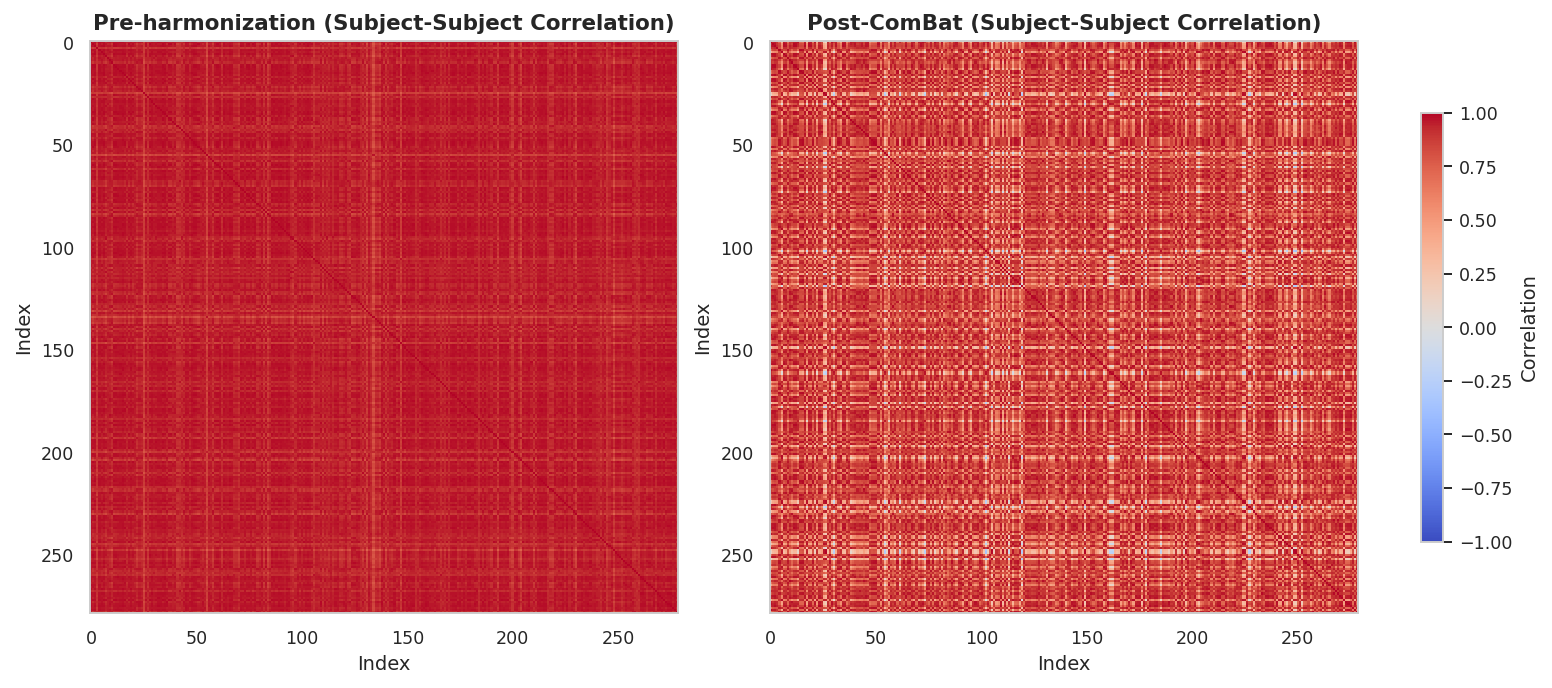

In [13]:
# Optional population-level region-wise subject-subject pre/post view
avail = available_regions(PREPOST, min_subjects=1)
REGION = int(avail.iloc[0]['parcel_idx'])
fig, axes = plot_region_covariance_side_by_side(PREPOST, region=REGION, mode='subject')


## 3) Coverage vs Accuracy


In [48]:
import src.eval_utils.results_eda as results_eda
importlib.reload(results_eda)

import src.eval_utils.results_eda
importlib.reload(src.eval_utils.results_eda)
from src.eval_utils.results_eda import *

,subject,model,coverage,n_loro_parcels,n_eval_genes,n_total_genes,eval_gene_mode,eval_gene_path,inverse_combat,clamp_zero,n_points,pearson_r,spearman_r,r2,rmse
0,GTEX-1192W,naive,5,5,13618,13618,all,None,False,False,68090,0.830004,0.869096,0.574283,1.127193
1,GTEX-131XW,naive,5,5,13618,13618,all,None,False,False,68090,0.853913,0.865389,0.554455,1.096063
2,GTEX-13NZA,naive,5,5,13618,13618,all,None,False,False,68090,0.822294,0.862225,0.514961,1.213825
3,GTEX-1477Z,naive,5,5,13618,13618,all,None,False,False,68090,0.823854,0.858986,0.535809,1.187866
4,GTEX-17MF6,naive,5,5,13618,13618,all,None,False,False,68090,0.821546,0.857661,0.516642,1.223745


,model,pearson_mean,pearson_std,spearman_mean,spearman_std,r2_mean,r2_std,rmse_mean,rmse_std,n_subjects,pearson_err,spearman_err,r2_err,rmse_err
0,naive,0.848140,0.022141,0.886744,0.018366,0.603218,0.054006,1.057406,0.100871,313,0.001251,0.001038,0.003053,0.005702
1,dlam,0.870626,0.097145,0.903374,0.054453,0.548557,0.760910,0.963615,0.577354,313,0.005491,0.003078,0.043009,0.032634
2,plam,0.865123,0.076576,0.887865,0.049004,0.697995,0.236762,0.878047,0.276645,313,0.004328,0.002770,0.013383,0.015637


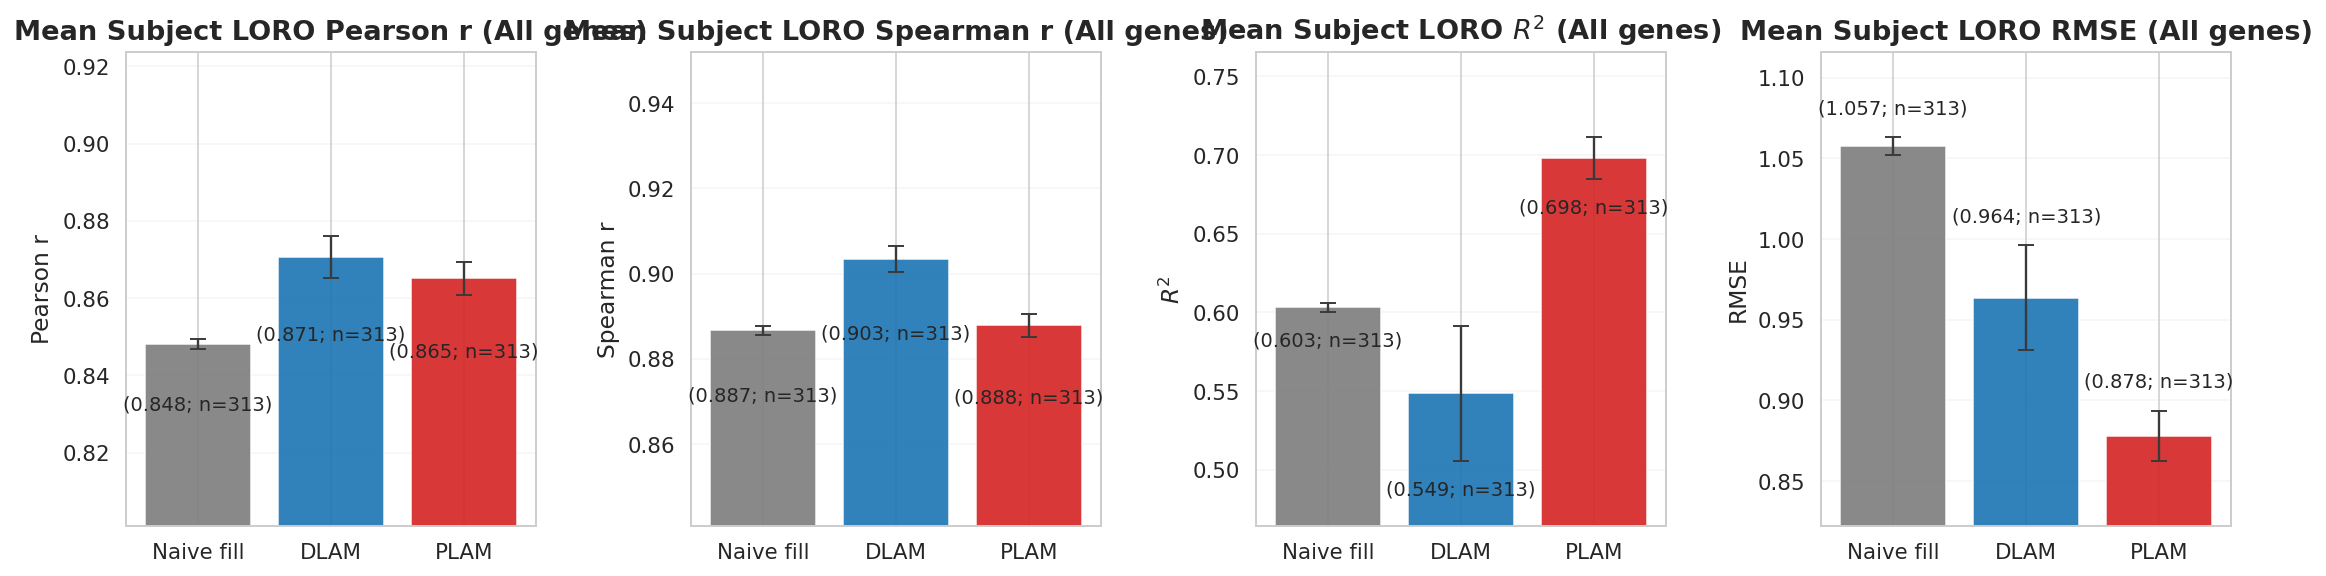

In [49]:
naive_all = compute_subject_metrics_from_cache_gene_subset(CFG, model='naive', n_jobs=16) # originally 30 secs
dlam_all  = compute_subject_metrics_from_cache_gene_subset(CFG, model='dlam',  n_jobs=16)
plam_all  = compute_subject_metrics_from_cache_gene_subset(CFG, model='plam',  n_jobs=16)
metrics_allgenes_eval = pd.concat([naive_all, dlam_all, plam_all], ignore_index=True)
display(metrics_allgenes_eval.head())

fig, axes, summary_all = plot_loro_subject_summary_bars(metrics_allgenes_eval, use_sem=True)
display(summary_all)


In [ ]:
from scipy.stats import ttest_rel
from itertools import combinations

# Helper to do paired t-tests and show results
def paired_ttests_by_subject(metrics_df, label=""):
    # Pivot table: rows are subject, cols are model, values are pearson_r
    pivot = metrics_df.pivot(index='subject', columns='model', values='pearson_r')
    # Only keep subjects present in all models
    pivot = pivot.dropna()
    # Paired t-tests between each pair of models
    model_names = pivot.columns.tolist()
    t_results = {}
    print(f"\nPaired t-tests for {label}:")
    for model1, model2 in combinations(model_names, 2):
        t_stat, p_val = ttest_rel(pivot[model1], pivot[model2])
        t_results[(model1, model2)] = {'t_stat': t_stat, 'p_val': p_val}
        print(f"  {model1} vs {model2}: t = {t_stat:.4f}, p = {p_val:.4g}")
    return pivot, t_results

pivot_allgenes, t_results_allgenes = paired_ttests_by_subject(metrics_allgenes_eval, label="all genes")
pivot_allgenes.head()


Paired t-tests for all genes:
  dlam vs naive: t = 3.9428, p = 9.95e-05
  dlam vs plam: t = 3.5520, p = 0.0004413
  naive vs plam: t = -3.7482, p = 0.0002122


model,dlam,naive,plam
subject,,,
GTEX-1117F,0.883132,0.886137,0.875760
GTEX-111FC,0.886696,0.846861,0.873026
GTEX-117XS,0.886923,0.851439,0.875711
GTEX-1192W,0.879600,0.830004,0.853585
GTEX-1192X,0.944760,0.843251,0.927970


,subject,model,coverage,n_loro_parcels,n_eval_genes,n_total_genes,eval_gene_mode,eval_gene_path,inverse_combat,clamp_zero,n_points,pearson_r,spearman_r,r2,rmse
0,GTEX-1192W,naive,5,5,103,13618,file:richiardi2015,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,False,False,515,0.781075,0.778728,0.390082,1.357443
1,GTEX-131XW,naive,5,5,103,13618,file:richiardi2015,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,False,False,515,0.845739,0.823157,0.433989,1.242877
2,GTEX-13NZA,naive,5,5,103,13618,file:richiardi2015,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,False,False,515,0.788484,0.782984,0.406208,1.420084
3,GTEX-1477Z,naive,5,5,103,13618,file:richiardi2015,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,False,False,515,0.786855,0.766174,0.371153,1.454818
4,GTEX-17MF6,naive,5,5,103,13618,file:richiardi2015,/scratch/asr655/neuroinformatics/Seq2GeneEx/gt...,False,False,515,0.791047,0.777341,0.377524,1.456552


,model,pearson_mean,pearson_std,spearman_mean,spearman_std,r2_mean,r2_std,rmse_mean,rmse_std,n_subjects,pearson_err,spearman_err,r2_err,rmse_err
0,naive,0.832035,0.026954,0.820764,0.026668,0.595746,0.109245,1.182672,0.123303,313,0.001524,0.001507,0.006175,0.006969
1,dlam,0.827828,0.071262,0.825014,0.059045,0.558194,0.408652,1.184381,0.423704,313,0.004028,0.003337,0.023098,0.023949
2,plam,0.831842,0.049986,0.820442,0.040070,0.637072,0.188930,1.109122,0.246100,313,0.002825,0.002265,0.010679,0.013910


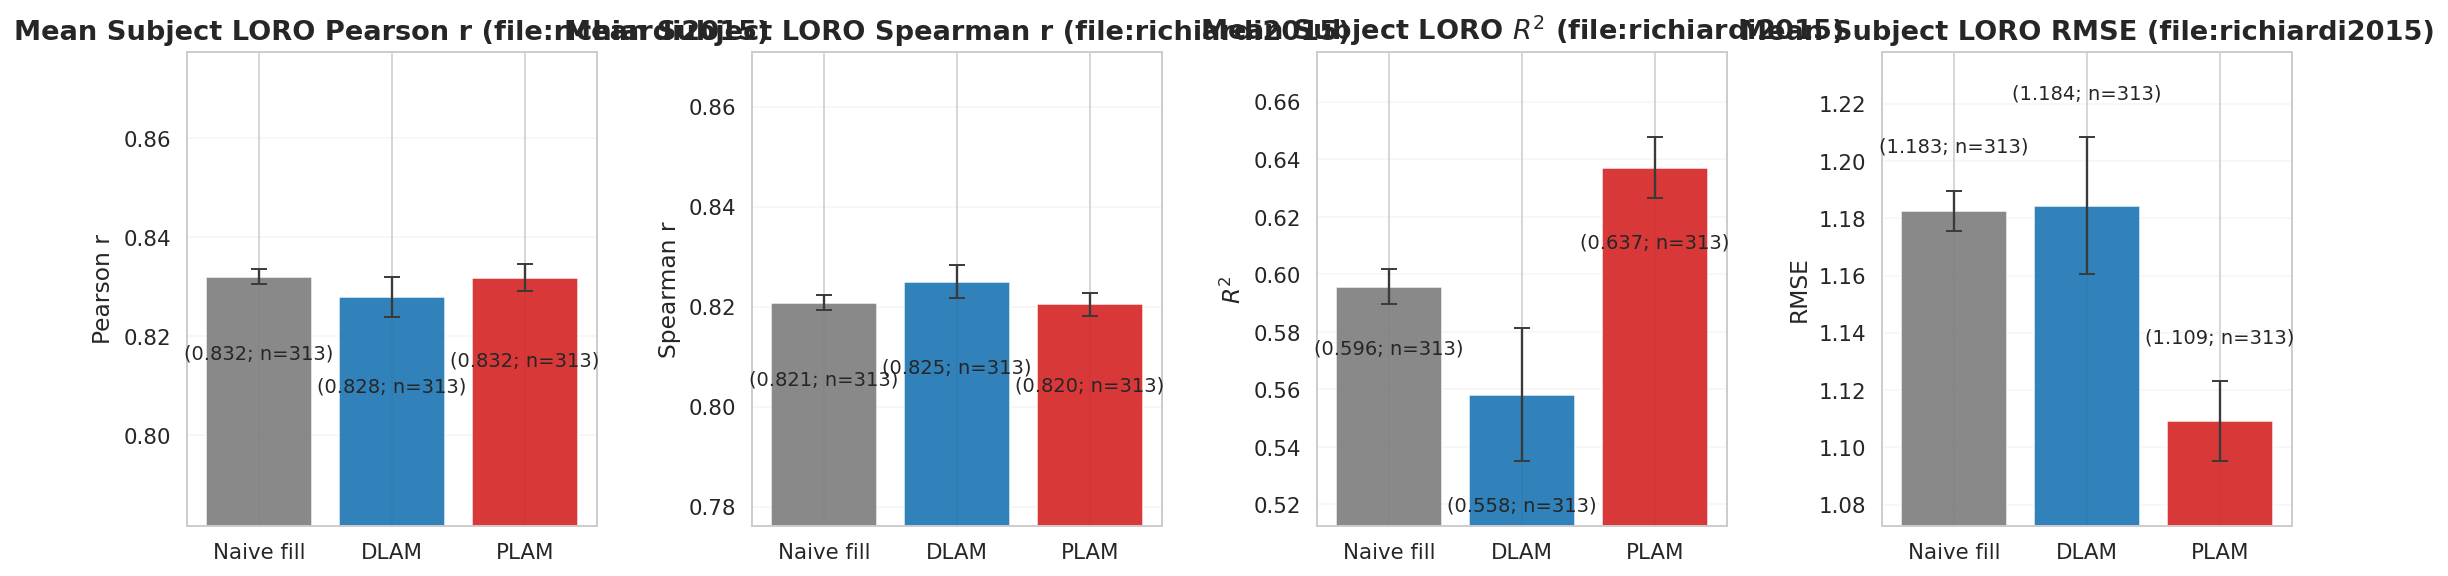

In [56]:
# allgenes-fit cache metrics, evaluated on HVG subset
naive_hvg = compute_subject_metrics_from_cache_gene_subset(CFG, model='naive', eval_gene_path='richiardi2015', n_jobs=16) # originally 30 secs
dlam_hvg  = compute_subject_metrics_from_cache_gene_subset(CFG, model='dlam',  eval_gene_path='richiardi2015', n_jobs=16)
plam_hvg  = compute_subject_metrics_from_cache_gene_subset(CFG, model='plam',  eval_gene_path='richiardi2015', n_jobs=16)
metrics_hvg_eval_on_allgenes_fit = pd.concat([naive_hvg, dlam_hvg, plam_hvg], ignore_index=True)
display(metrics_hvg_eval_on_allgenes_fit.head())

fig, axes, summary_all = plot_loro_subject_summary_bars(metrics_hvg_eval_on_allgenes_fit, use_sem=True)
display(summary_all)


,model,pearson_mean,pearson_std,spearman_mean,spearman_std,r2_mean,r2_std,rmse_mean,rmse_std,n_subjects,pearson_err,spearman_err,r2_err,rmse_err
0,naive,0.854977,0.033215,0.846948,0.031909,0.607480,0.198020,1.348905,0.214844,313,0.001877,0.001804,0.011193,0.012144
1,dlam,0.772304,0.096060,0.770850,0.095345,0.424202,0.429358,1.622158,0.536334,313,0.005430,0.005389,0.024269,0.030315
2,plam,0.822537,0.045378,0.815982,0.043029,0.583585,0.201222,1.407340,0.305233,313,0.002565,0.002432,0.011374,0.017253


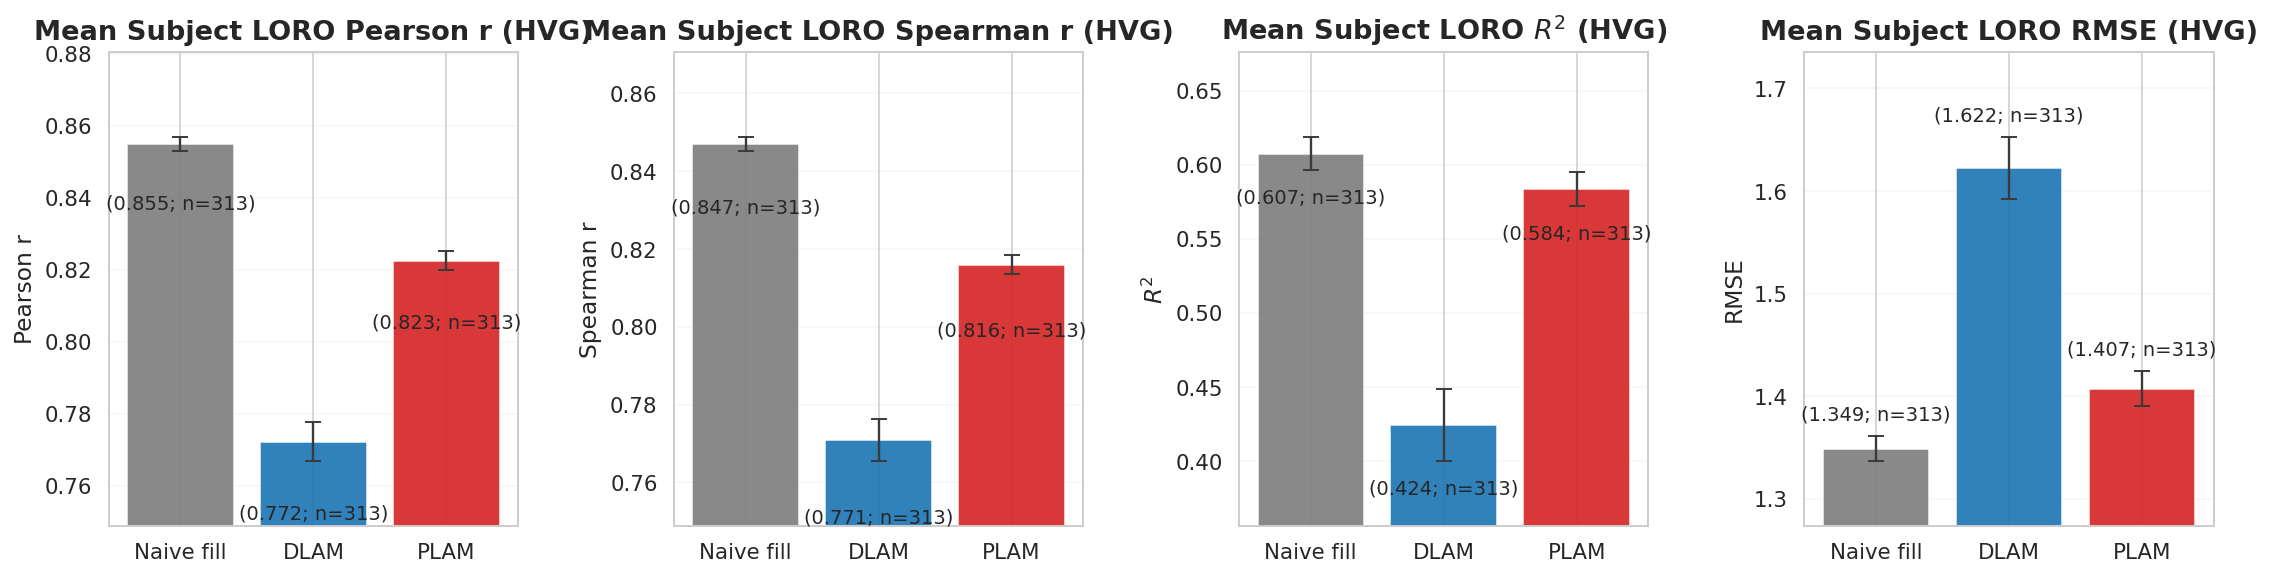

In [44]:
fig, axes, summary_all = plot_loro_subject_summary_bars(metrics_hvg_eval_on_allgenes_fit, use_sem=True)
display(summary_all)

In [30]:
pivot_hvg, t_results_hvg = paired_ttests_by_subject(metrics_hvg_eval_on_allgenes_fit, label="HVG (fit on all genes)")
pivot_hvg.head()


Paired t-tests for HVG (fit on all genes):
  dlam vs naive: t = -14.0140, p = 6.026e-35
  dlam vs plam: t = -9.8129, p = 5.501e-20
  naive vs plam: t = 15.3406, p = 5.713e-40


model,dlam,naive,plam
subject,,,
GTEX-1117F,0.670338,0.874235,0.878290
GTEX-111FC,0.700391,0.888942,0.871896
GTEX-117XS,0.723931,0.884988,0.841299
GTEX-1192W,0.699868,0.840372,0.828332
GTEX-1192X,0.756564,0.870192,0.854012


## 4) Fold-Combo Difficulty


In [ ]:
fold_perf_df, combo_df = compute_fold_combo_metrics_from_cache(
    CFG, PREPOST,
    eval_gene_mode='all',
    custom_gene_list=None,
    coverage_min=5,
    coverage_max=11,
    models=['naive', 'dlam', 'plam'],
)
print('fold_perf_df:', fold_perf_df.shape)
print('combo_df:', combo_df.shape)
display(combo_df.head())


,rank_tag,model,metric,score,coverage,n_subjects,fold_key,hold_parcel,hold_gtex,train_parcels,train_gtex
0,worst,naive,mean_pearson,0.585803,7,1,"hold=38|train=12,16,18,21,93,132",38,frontal cortex (ba9),"[12, 16, 18, 21, 93, 132]",[caudate (basal ganglia); putamen (basal gangl...
1,median,naive,mean_pearson,0.741124,6,1,"hold=12|train=5,18,38,109,132",12,caudate (basal ganglia); putamen (basal ganglia),"[5, 18, 38, 109, 132]","[cerebellar hemisphere, nucleus accumbens (bas..."
2,best,naive,mean_pearson,0.823113,10,1,"hold=16|train=0,5,12,21,38,88,93,109,132",16,hypothalamus,"[0, 5, 12, 21, 38, 88, 93, 109, 132]","[cerebellum, cerebellar hemisphere, caudate (b..."


,rank_tag,model,metric,score,coverage,n_subjects,fold_key,hold_parcel,hold_gtex,train_parcels,train_gtex
0,worst,dlam,mean_pearson,0.361104,8,1,"hold=88|train=0,5,12,16,18,109,132",88,amygdala,"[0, 5, 12, 16, 18, 109, 132]","[cerebellum, cerebellar hemisphere, caudate (b..."
1,median,dlam,mean_pearson,0.898694,8,2,"hold=132|train=0,5,12,16,18,21,38",132,anterior cingulate cortex (ba24),"[0, 5, 12, 16, 18, 21, 38]","[cerebellum, cerebellar hemisphere, caudate (b..."
2,best,dlam,mean_pearson,0.984160,6,1,"hold=18|train=12,38,88,109,132",18,nucleus accumbens (basal ganglia),"[12, 38, 88, 109, 132]",[caudate (basal ganglia); putamen (basal gangl...


,rank_tag,model,metric,score,coverage,n_subjects,fold_key,hold_parcel,hold_gtex,train_parcels,train_gtex
0,worst,plam,mean_pearson,0.502324,8,1,"hold=88|train=0,5,12,16,18,109,132",88,amygdala,"[0, 5, 12, 16, 18, 109, 132]","[cerebellum, cerebellar hemisphere, caudate (b..."
1,median,plam,mean_pearson,0.866700,9,1,"hold=38|train=12,16,18,21,88,93,109,132",38,frontal cortex (ba9),"[12, 16, 18, 21, 88, 93, 109, 132]",[caudate (basal ganglia); putamen (basal gangl...
2,best,plam,mean_pearson,0.963744,6,1,"hold=12|train=0,16,18,21,109",12,caudate (basal ganglia); putamen (basal ganglia),"[0, 16, 18, 21, 109]","[cerebellum, hypothalamus, nucleus accumbens (..."


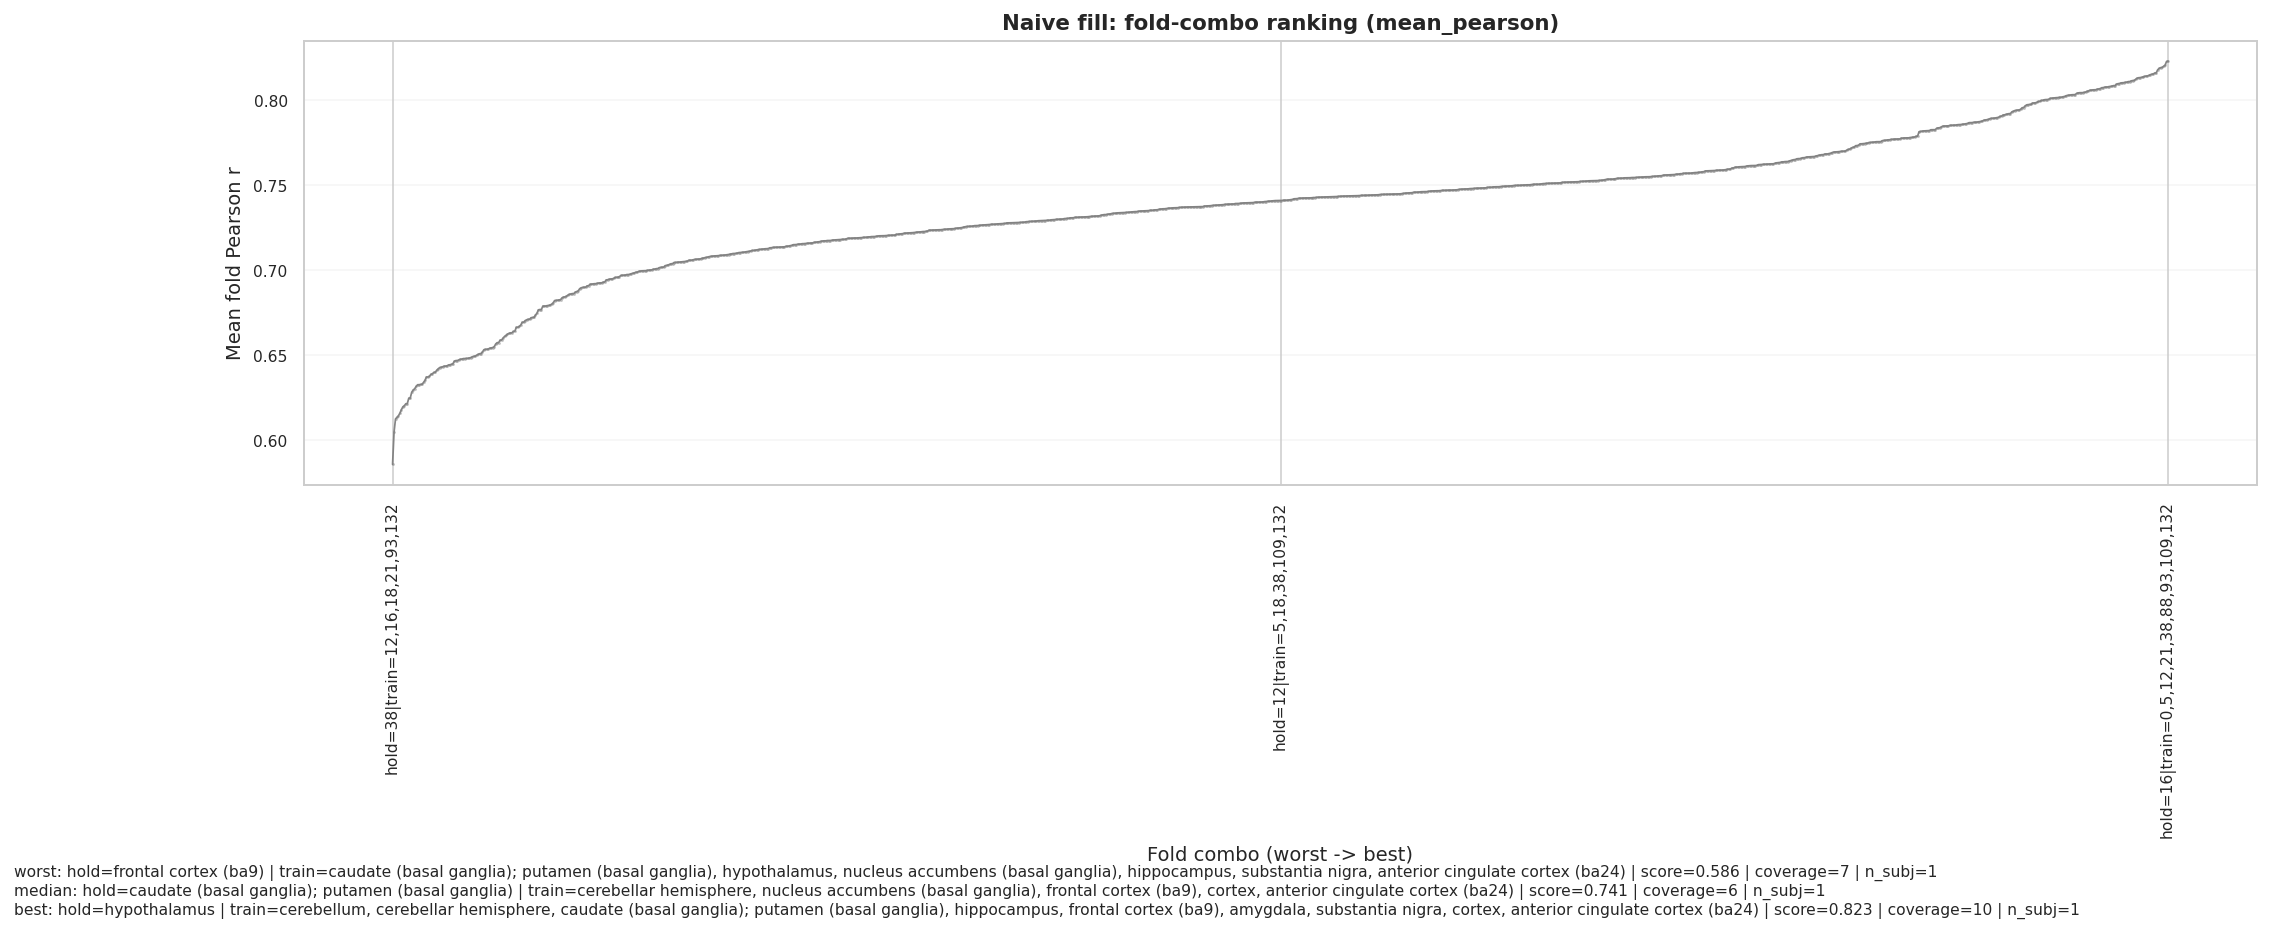

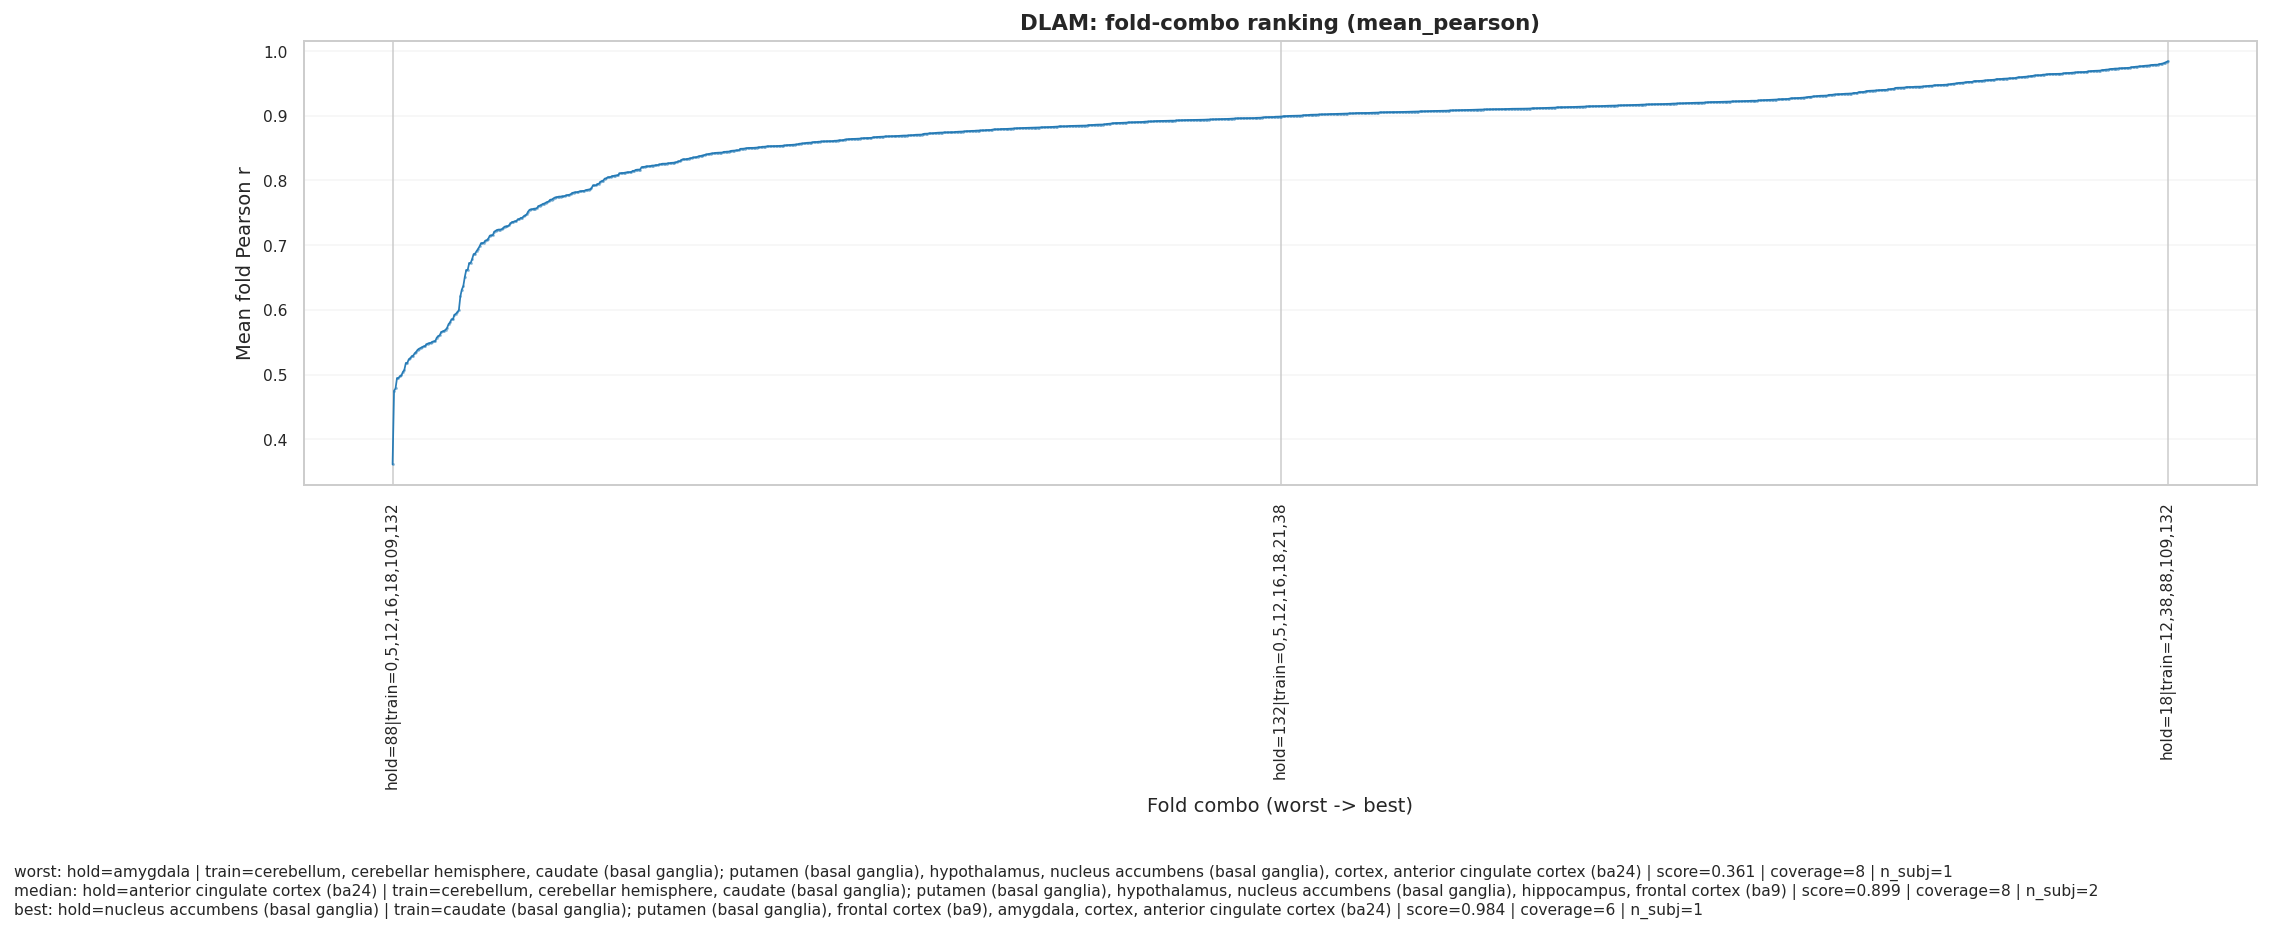

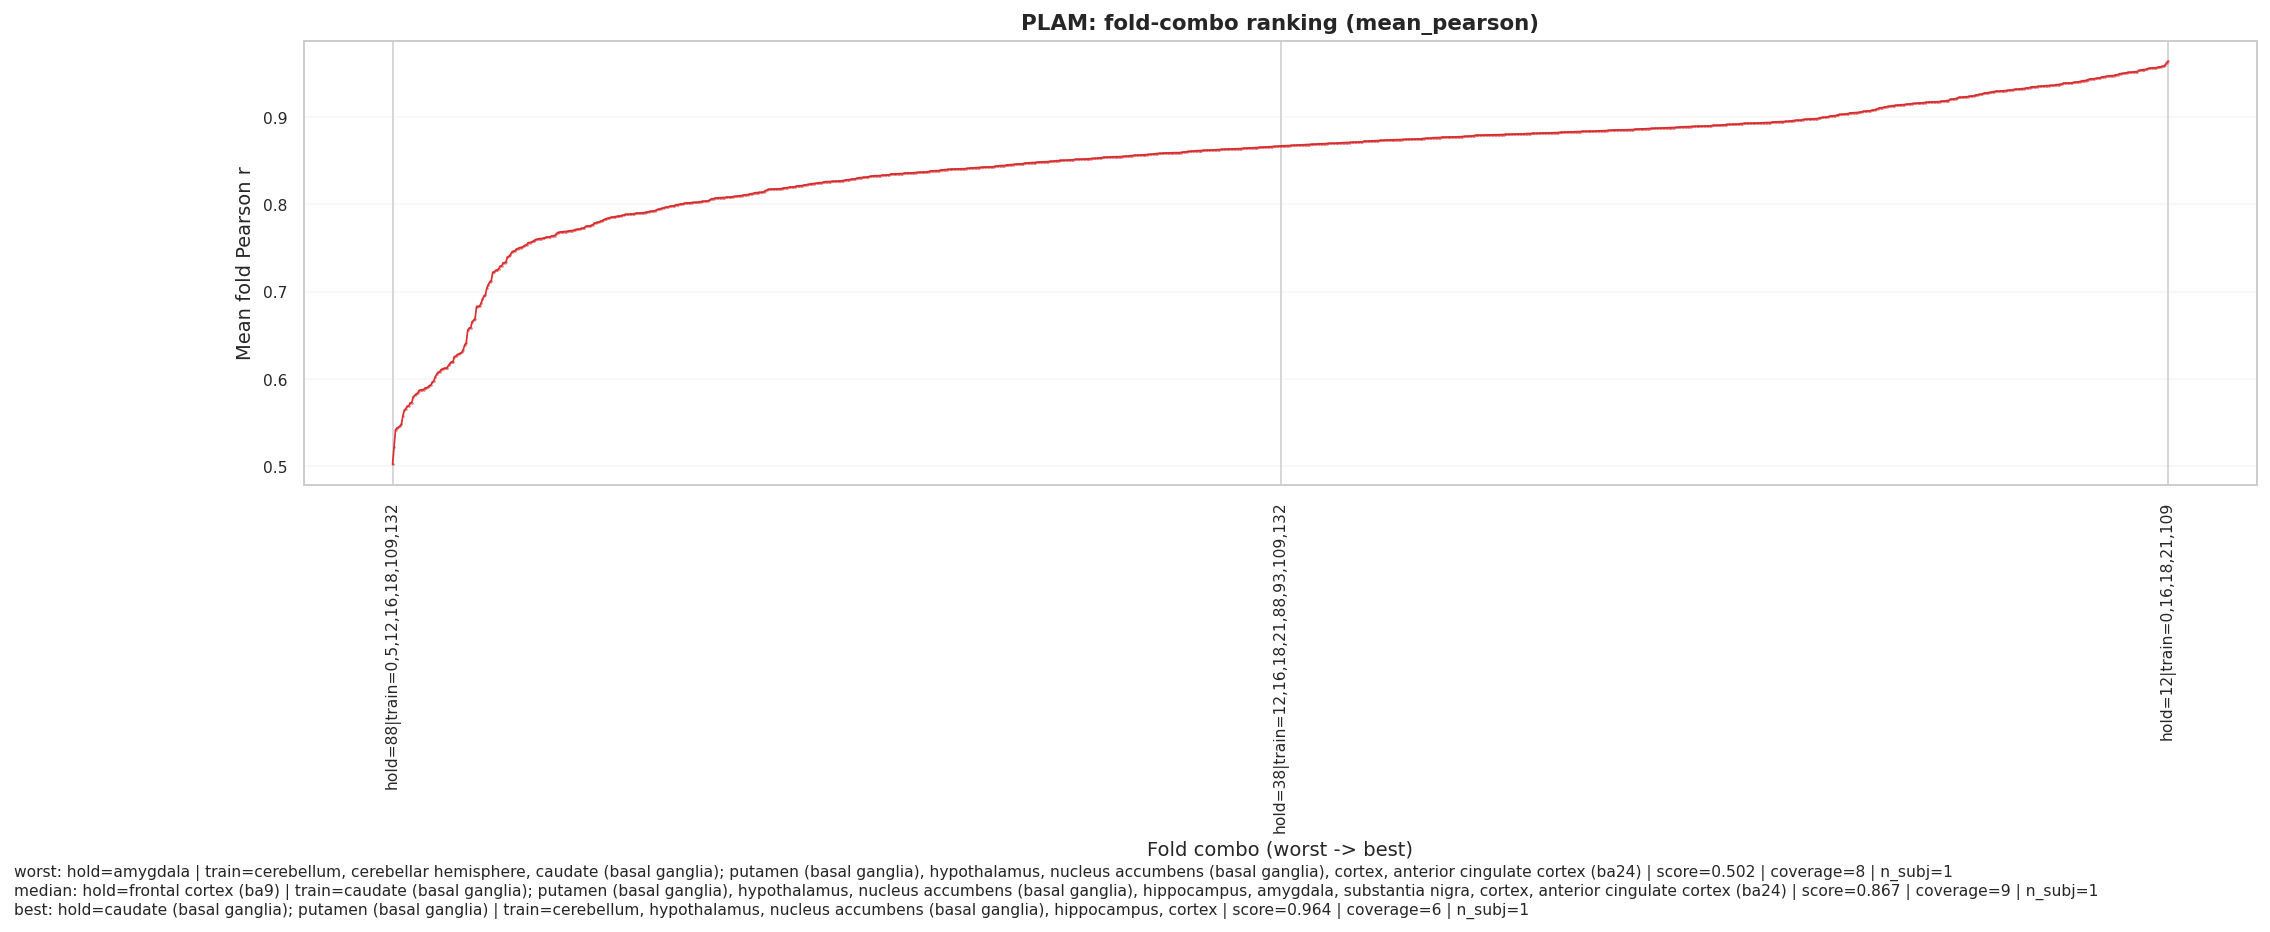

In [ ]:
for model_name in ['naive', 'dlam', 'plam']:
    fig, ax, key_table = plot_fold_combo_ranked(combo_df, PREPOST, model=model_name, metric='mean_pearson')
    display(key_table)


,hold_parcel,model,n_subjects,n_folds,mean_pearson,std_pearson,mean_rmse,std_rmse,gtex_label,ahba_label,label
0,0,dlam,251,251,0.887645,0.096795,0.971644,0.659322,cerebellum,Cerebellar_Region1,cerebellum
1,0,naive,251,251,0.759283,0.025393,1.289612,0.097651,cerebellum,Cerebellar_Region1,cerebellum
2,0,plam,251,251,0.864881,0.081653,1.006555,0.474752,cerebellum,Cerebellar_Region1,cerebellum
3,5,dlam,261,261,0.880474,0.106908,0.983054,0.658201,cerebellar hemisphere,Cerebellar_Region5,cerebellar hemisphere
4,5,naive,261,261,0.765969,0.026122,1.233572,0.106519,cerebellar hemisphere,Cerebellar_Region5,cerebellar hemisphere
5,5,plam,261,261,0.857539,0.089166,1.021630,0.457638,cerebellar hemisphere,Cerebellar_Region5,cerebellar hemisphere
6,12,dlam,293,293,0.887051,0.101901,0.952599,0.617908,caudate (basal ganglia); putamen (basal ganglia),LH-EXA,caudate (basal ganglia); putamen (basal ganglia)
7,12,naive,293,293,0.749015,0.032174,1.421056,0.143254,caudate (basal ganglia); putamen (basal ganglia),LH-EXA,caudate (basal ganglia); putamen (basal ganglia)
8,12,plam,293,293,0.873963,0.082137,0.962142,0.401393,caudate (basal ganglia); putamen (basal ganglia),LH-EXA,caudate (basal ganglia); putamen (basal ganglia)
9,16,dlam,241,241,0.880191,0.097796,0.974008,0.577174,hypothalamus,LH-HTH,hypothalamus


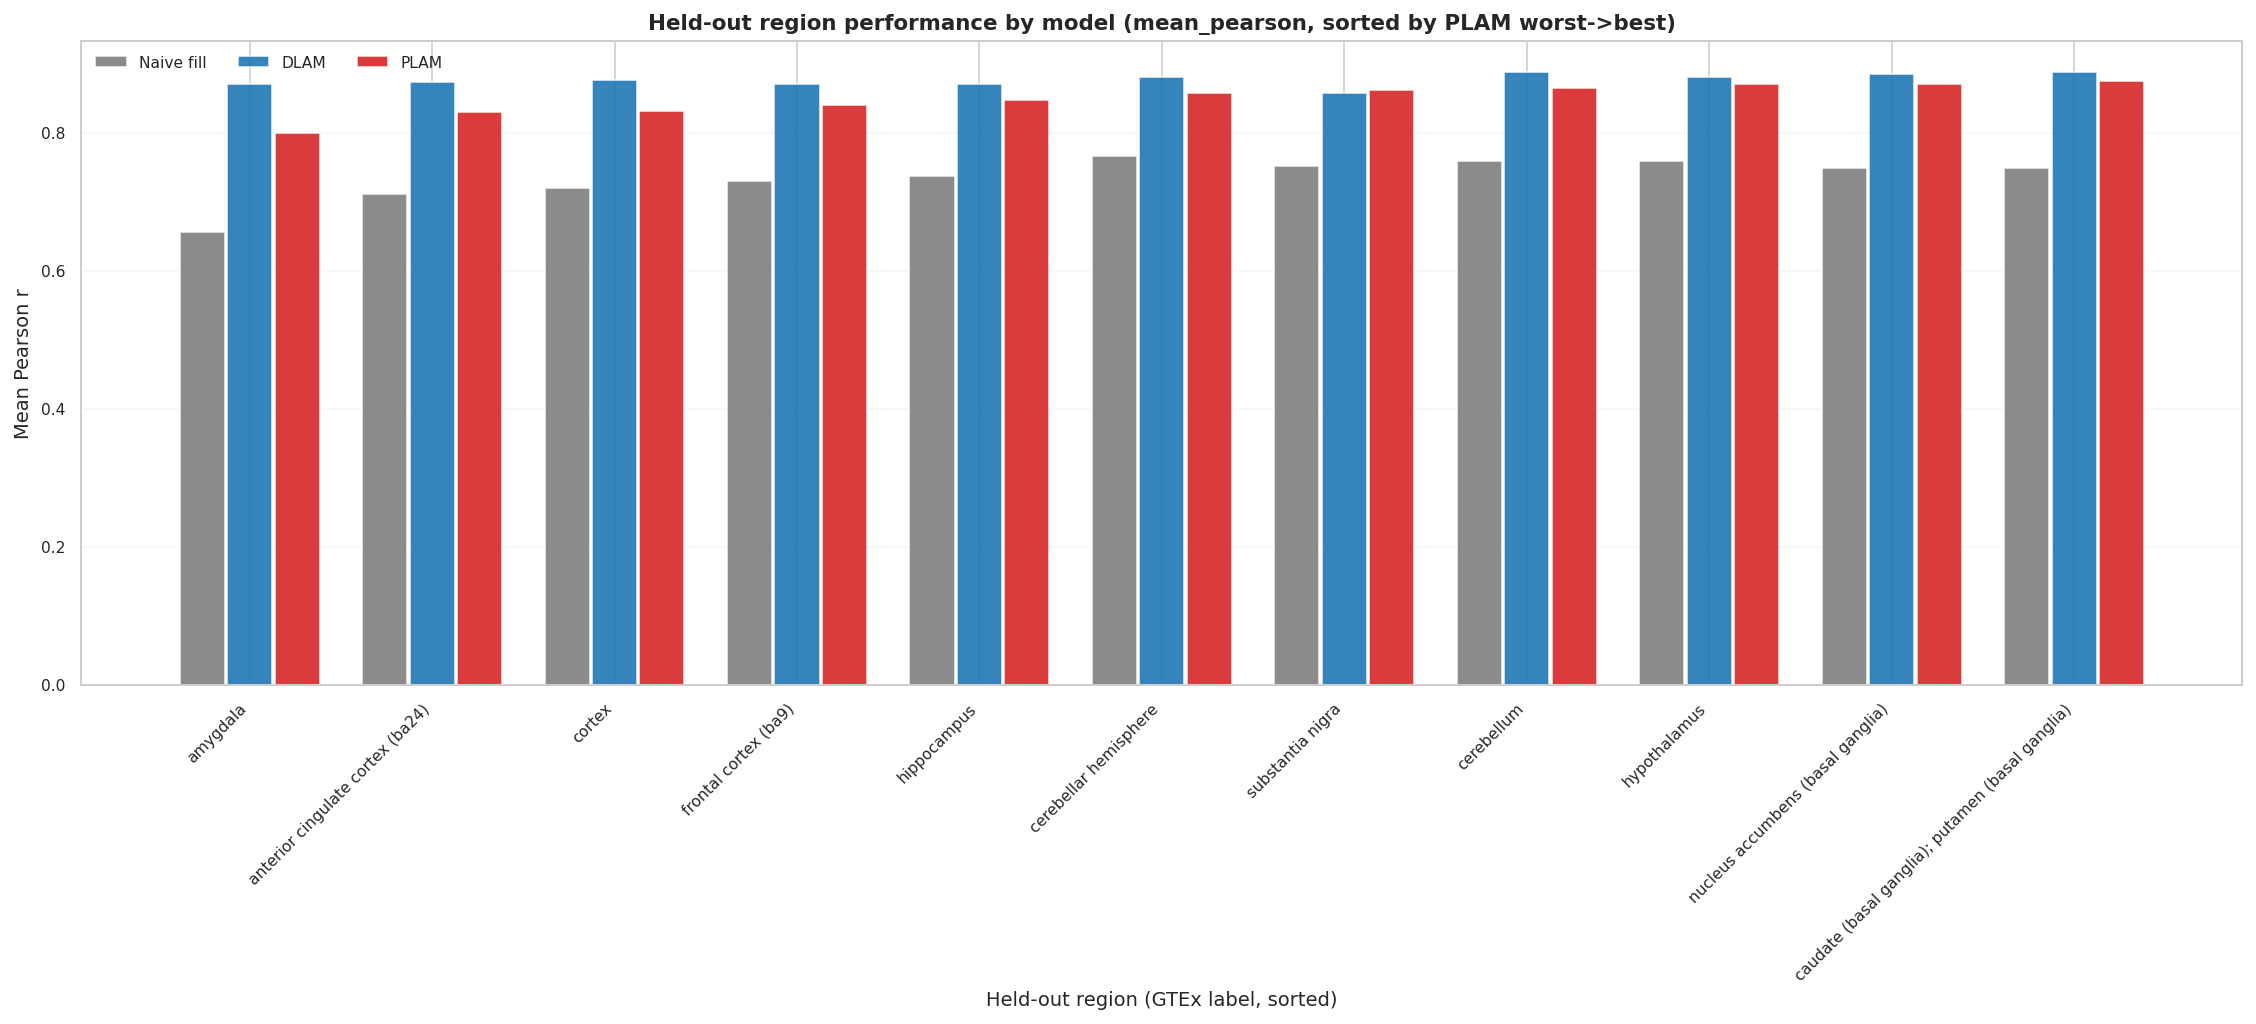

In [ ]:
heldout_df = summarize_heldout_region_performance(fold_perf_df, PREPOST)
fig, ax, heldout_plot_df = plot_heldout_region_grouped_bars(
    heldout_df,
    metric='mean_pearson',
    sort_by_model='plam',
    use_error_bars=False,
    error_kind='std',
)
display(heldout_df.head(20))

## 5) Single-Subject Scatter Triplets


subject: GTEX-1HUB1


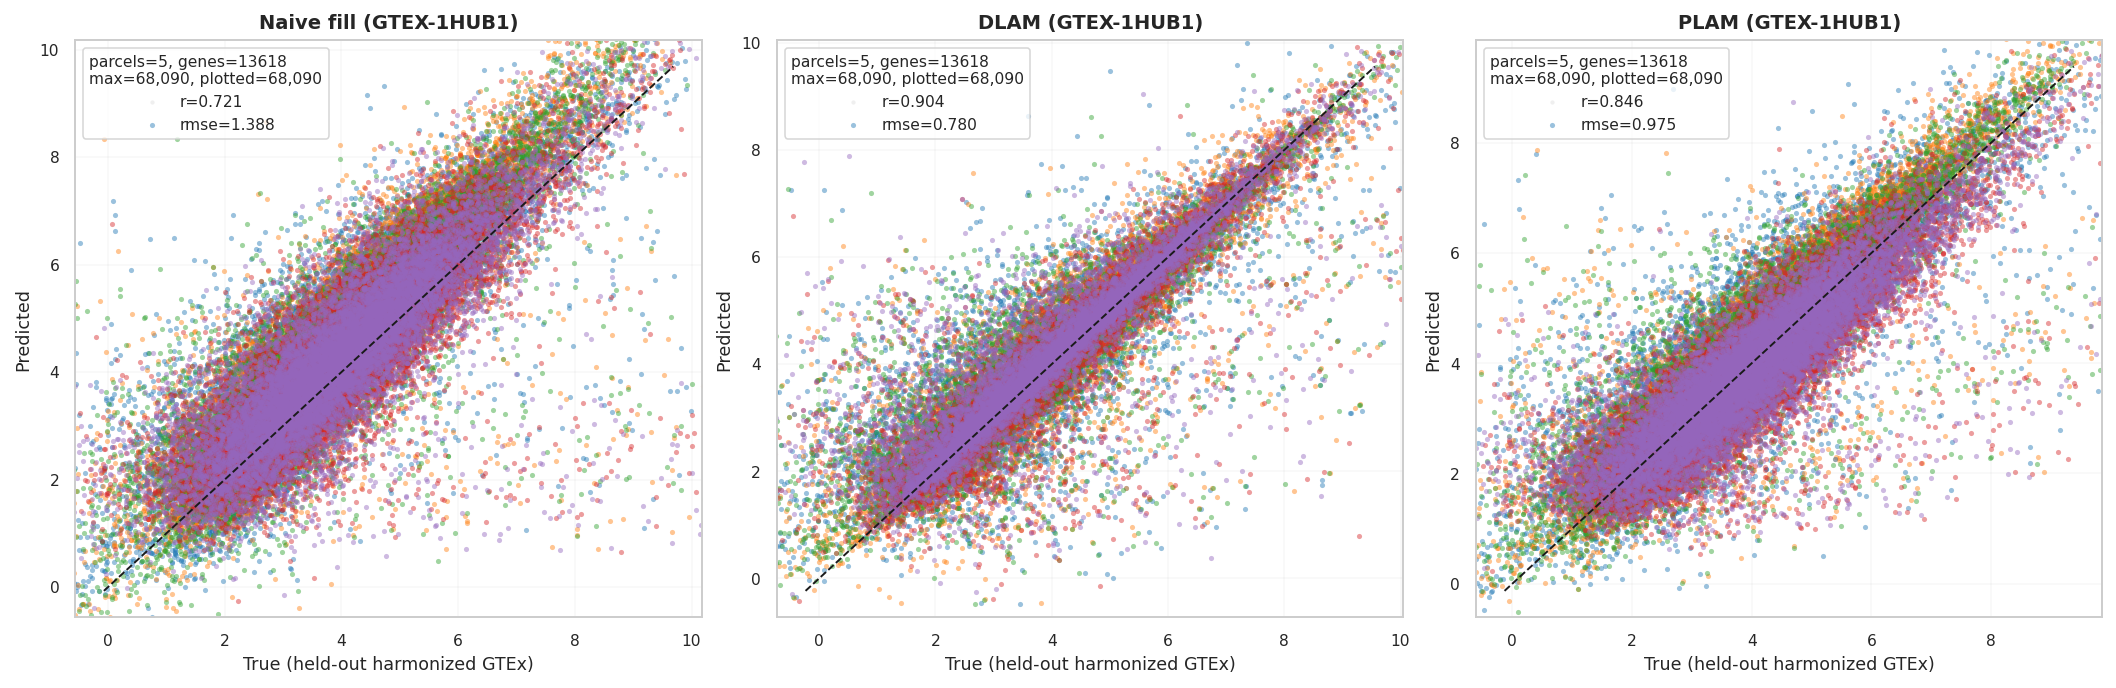

In [ ]:
fig, axes, subject = plot_single_subject_scatter_triplet(
    CFG,
    subject_mode='median',
    color_by='parcel',
    top_n=10,
)
print('subject:', subject)


subject: GTEX-1HUB1


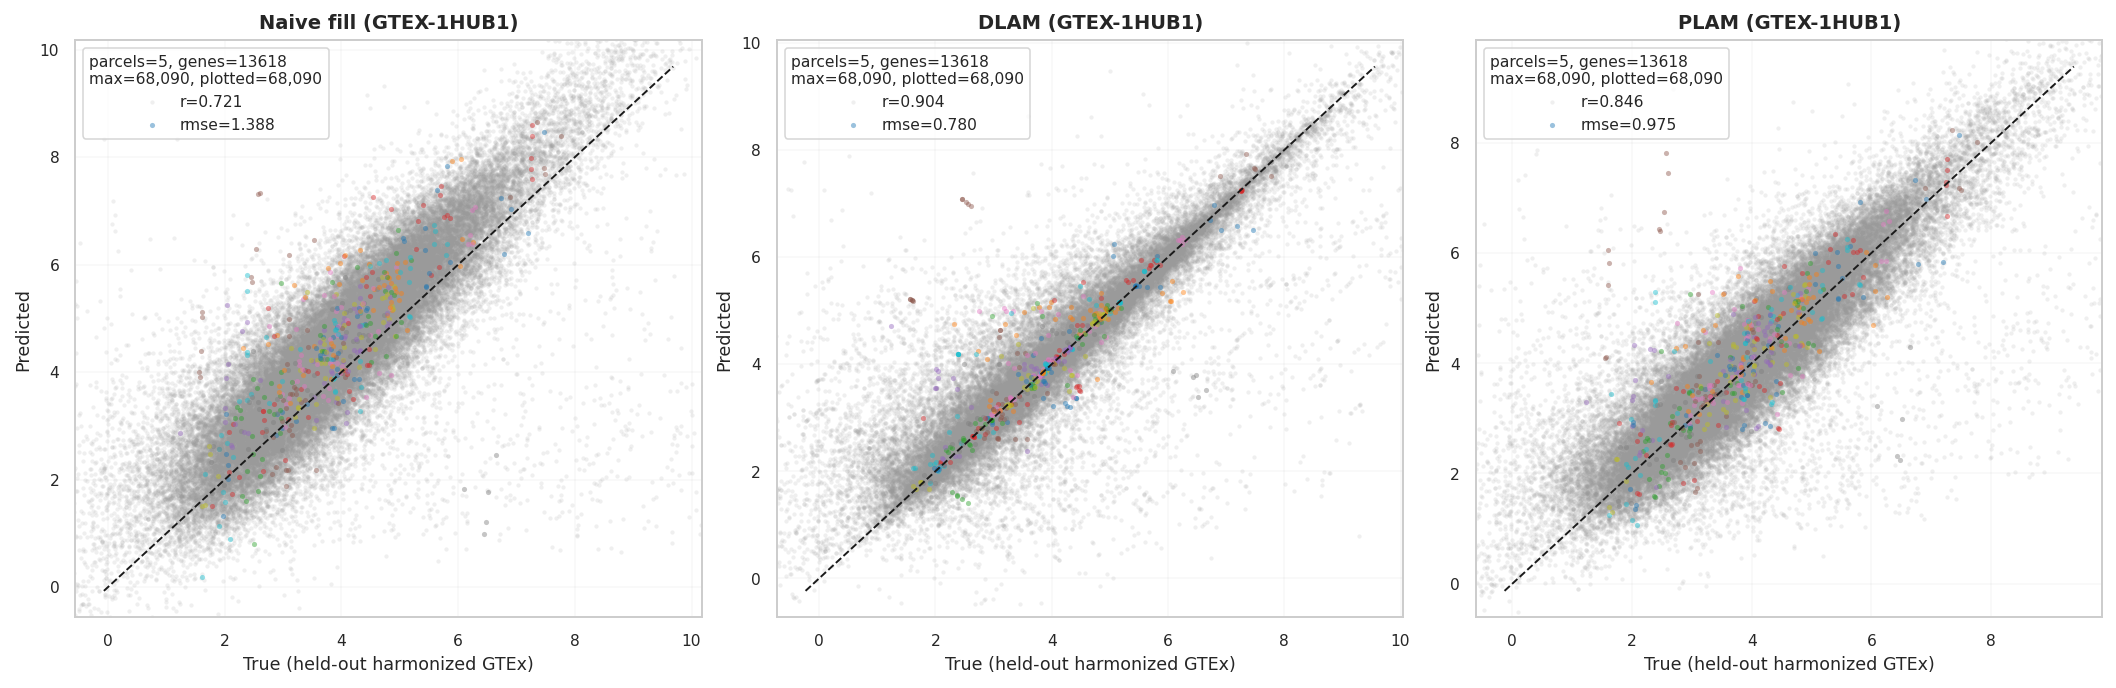

In [ ]:
fig, axes, subject = plot_single_subject_scatter_triplet(
    CFG,
    subject_mode='median',
    color_by='gene',
    top_n=100,
)
print('subject:', subject)
